In [153]:
import sys
sys.path.append('..')
from src.utils import section
import joblib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error


In [154]:
from src.data_load import data_loader
# Load data
df = data_loader('../data/raw/influencer_campaign_regression.csv')
df.head()

,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,avg_watch_time_sec,promo_discount_pct,content_format,audience_intent_tier,caption_word_count,hashtags_used_count,creator_phone_os,contract_payment_terms,posting_day_weather,campaign_revenue_usd
0,425.4,2.14,1331.0,35.2,10,Static-Carousel,High-Intent-Niche,35,16,Android,Net-30,Sunny,15192.26
1,171.3,5.73,3925.0,25.4,10,YouTube-Deep-Dive,Lifestyle-Warm,26,16,Android,Upfront,Cloudy,20018.44
2,356.4,8.03,1817.0,9.4,0,Short-Video-Reel,High-Intent-Niche,43,24,Android,Upfront,Cloudy,21146.87
3,272.2,7.70,942.0,32.1,15,Short-Video-Reel,Lifestyle-Warm,113,9,Android,Net-15,Rainy,17639.62
4,143.0,6.06,3347.0,51.0,20,Short-Video-Reel,Broad-Entertainment,72,18,Android,Net-30,Cloudy,17375.60


In [155]:
# Train test split
from src.train import train_test_splitter
X_train, X_test, y_train, y_test = train_test_splitter(df, ['campaign_revenue_usd'], 'campaign_revenue_usd', False)

# Preprocessor
from src.pipeline import pipeline_builder
preprocessor = pipeline_builder(df, ['campaign_revenue_usd'])

# Model training Pipeline
from src.train import full_pipeline_builder

# Linear regression
linear_regression_pipeline = full_pipeline_builder(df,
                                                   LinearRegression(),
                                                   ['campaign_revenue_usd'],
                                                   False
                                                   )

# Random forest
random_forest_pipeline = full_pipeline_builder(df,
                                               RandomForestRegressor(),
                                                ['campaign_revenue_usd'],
                                                False                                               
                                               )

# XGboost
xgboost_pipeline = full_pipeline_builder(df,
                                            XGBRegressor(),
                                            ['campaign_revenue_usd'],
                                            False                                               
                                            )

# Lightgbm
lightgbm_pipeline = full_pipeline_builder(df,
                                            LGBMRegressor(),
                                            ['campaign_revenue_usd'],
                                            False                                               
                                            )

# Cross validation
section('cross validation', 45)
models = {
    "Linear Regression": linear_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
    "LightGBM": lightgbm_pipeline,
}

models_performance = {}

for model_name, model_pipeline in models.items():
    scores = cross_validate(model_pipeline,
                            X_train,y_train,
                            cv = 5,
                            scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']
                            )
    models_performance[model_name] = scores

                                             
CROSS VALIDATION:
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1032
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 10
[LightGBM] [Info] Start training from score 16717.716006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1033
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 10
[LightGBM] [Info] Start training from score 16662.603919
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1034
[LightGBM] [Info] Number of data points in the tra

In [156]:
rows = {}

for model_name, scores in models_performance.items():
    rows[model_name] = {
        "R2 %": round((scores["test_r2"].mean()) * 100,3) ,
        "MAE": -1 * (scores["test_neg_mean_absolute_error"].mean()),
        "RMSE": -1 * (scores["test_neg_root_mean_squared_error"].mean()),
        "Error %": round((-1 * (scores['test_neg_mean_absolute_percentage_error'].mean())) * 100, 3)
    }

results_df = pd.DataFrame(rows).T
results_df.round(3)

,R2 %,MAE,RMSE,Error %
Linear Regression,97.286,612.740,778.038,4.065
Random Forest,91.112,1106.248,1407.146,7.410
XGBoost,95.189,822.418,1036.210,5.423
LightGBM,96.966,647.184,821.937,4.293


                                             
MODELS PERFORMANCE COMPARISON:


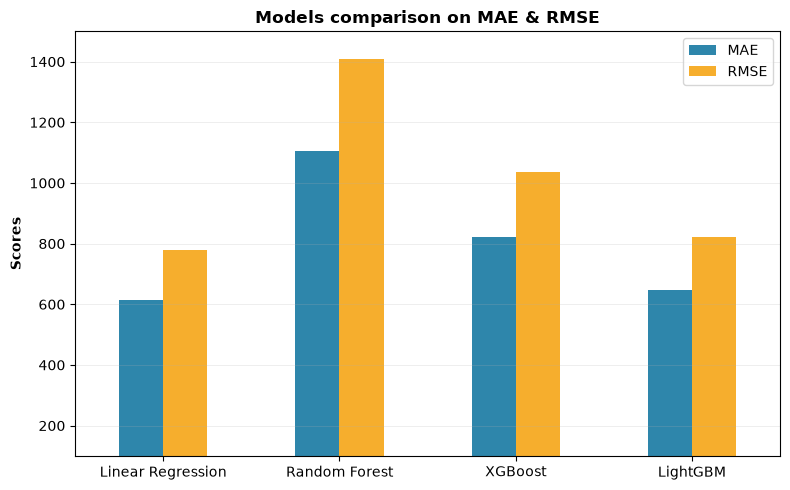

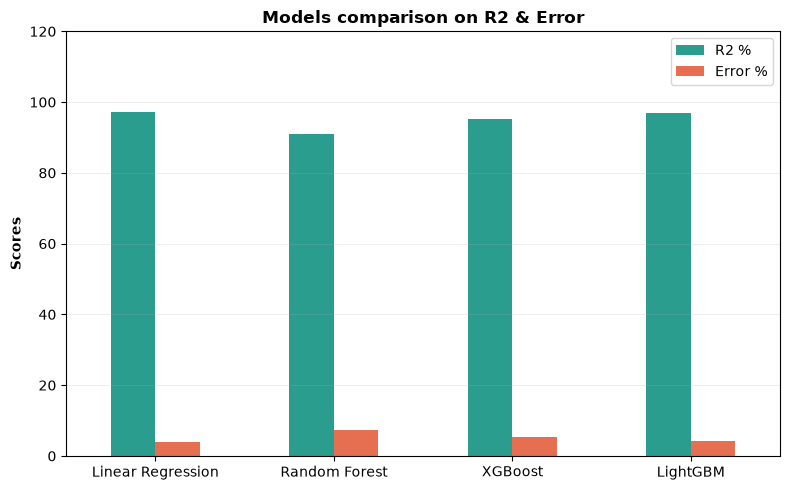

In [157]:
# Visulize models comparison
section('models performance comparison', 45)
results_df[['MAE', 'RMSE']].plot(kind='bar',
                                figsize=(8,5), 
                                color=['#2E86AB', '#F6AE2D']
                                )
plt.ylim(100, 1500)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.title('Models comparison on MAE & RMSE', fontweight='bold')
plt.ylabel("Scores", fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../figures/evaluation/regression_mae_rmse.png", dpi=600, bbox_inches='tight')
plt.show()

results_df[['R2 %', 'Error %']].plot(kind='bar',
                                figsize=(8,5), 
                                color=['#2A9D8F', '#E76F51']
                                )
plt.ylim(0, 120)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.title('Models comparison on R2 & Error', fontweight='bold')
plt.ylabel("Scores", fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../figures/evaluation/regression_r2_error.png", dpi=600, bbox_inches='tight')
plt.show()

In [158]:
# Hyperparameter tuning


grid_params = {
    'selector__k': [5, 8, 10, 12, 15, 18, 'all']
}

grid = GridSearchCV(
    linear_regression_pipeline,
    grid_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

joblib.dump(best_model, '../../backend/models/regression_model.pkl')

print(grid.best_params_)
print(-1 * grid.best_score_)

{'selector__k': 12}
777.6562212747076


In [159]:
# Model evaluation

section('evalution', 30)
y_pred = best_model.predict(X_test)

r_2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"""
R2%:            {round(r_2 * 100, 3)}%
MAE:            {round(mae, 3)}
RMSE:           {round(rmse, 3)}
Error%:         {round(mape * 100, 3)}%
""")

                              
EVALUTION:

R2%:            97.254%
MAE:            624.277
RMSE:           797.204
Error%:         4.218%



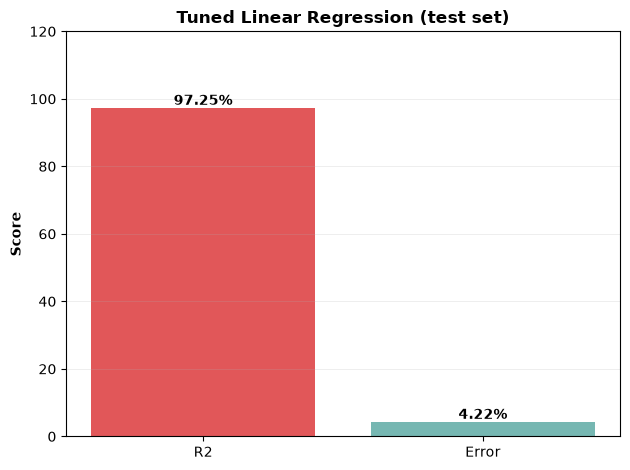

In [173]:
metrics = ['R2', 'Error']
values = [r_2 * 100, mape * 100]

bars = plt.bar(
            metrics,
            values,
            color = ['#E15759', '#76B7B2']
        )
plt.bar_label(bars, fmt='%.2f%%', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.ylim(0, 120)
plt.title("Tuned Linear Regression (test set)", fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/evaluation/regression_final_performance.png", dpi=600, bbox_inches='tight')
plt.show()